In [1]:
!pip install torch torchvision matplotlib

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Smaller subset for speed
subset_size = 5000

train_subset, _ = torch.utils.data.random_split(
    train_dataset,
    [subset_size, len(train_dataset) - subset_size]
)

train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=8,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [13]:
class ManualConv2D(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()

        self.kernel_size = kernel_size

        self.weight = nn.Parameter(
            torch.empty(out_channels, in_channels, kernel_size, kernel_size)
        )

        nn.init.xavier_uniform_(self.weight)

        self.bias = nn.Parameter(torch.zeros(out_channels))


    def forward(self, x):

        batch_size, in_channels, height, width = x.shape
        k = self.kernel_size

        patches = F.unfold(x, kernel_size=k)

        weight_flat = self.weight.view(self.weight.size(0), -1)

        output = weight_flat @ patches

        output = output + self.bias.view(1, -1, 1)

        out_height = height - k + 1
        out_width = width - k + 1

        output = output.view(batch_size, -1, out_height, out_width)

        return output

In [14]:
class ManualMaxPool(nn.Module):

    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size


    def forward(self, x):
        return F.max_pool2d(x, self.kernel_size)

In [15]:
class ManualCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = ManualConv2D(3, 8, 3)
        self.pool1 = ManualMaxPool(2)

        self.conv2 = ManualConv2D(8, 16, 3)
        self.pool2 = ManualMaxPool(2)

        self.fc1 = nn.Linear(16 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [16]:
model = ManualCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [20]:
epochs = 10

for epoch in range(epochs):

    running_loss = 0

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 1.2378
Epoch 2, Loss: 1.1564
Epoch 3, Loss: 1.0735
Epoch 4, Loss: 1.0087
Epoch 5, Loss: 0.9266
Epoch 6, Loss: 0.8560
Epoch 7, Loss: 0.7798
Epoch 8, Loss: 0.6948
Epoch 9, Loss: 0.6198
Epoch 10, Loss: 0.5449


In [21]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 48.4


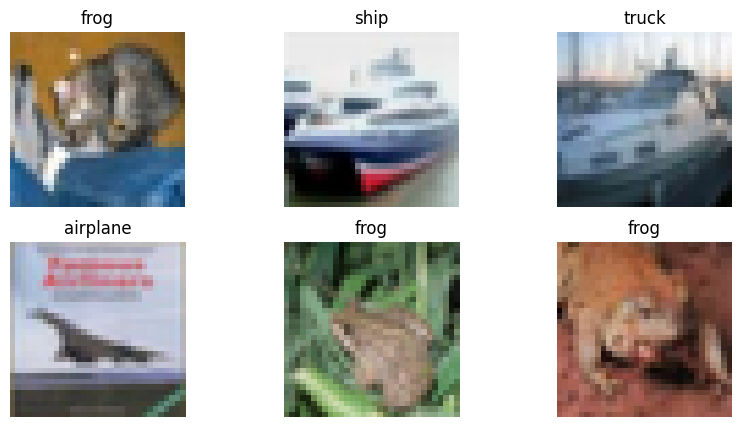

In [22]:
classes = train_dataset.classes

images, labels = next(iter(test_loader))

outputs = model(images.to(device))

_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = images[i].permute(1,2,0) * 0.5 + 0.5

    plt.imshow(img)
    plt.title(classes[preds[i]])
    plt.axis("off")

plt.show()